# Empirically obtained Feedback parameters
Here I look into the effective heat capacity and feedback parameters obtained empirically - this is simple when considering dry simulations with no evaporation as latent and sensible heat are turned off.

Main takeaway is that we still see a discrepancy between the effective parameters obtained using these feedback parameters, and that obtained from the direct Fourier fit.

I think this is because of the empirical relations between lowest model level temperature, and radiative and column integrated temperature: in reality their link is not as simple as this, need to solve differential equations at each pressure level, but this is complicated by the convection scheme which introduces a tendency term at different pressure levels.

In [1]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D
import scipy.optimize
from scipy.interpolate import CubicSpline, UnivariateSpline

from sympy.abc import lamda

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.surface_flux_taylor import name_square
from isca_tools.thesis.surface_flux_taylor_2layer import get_sensitivity_lw_surf
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g
from isca_tools.utils import numerical
from isca_tools.utils.radiation import get_heat_capacity
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr, fourier_series_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [3]:
# Must be the dry simulation with no specific humidity for this notebook
exp_name = [f"thesis_season/column/depth={i}/no_wind_dry" for i in [5, 20]]
ds_base = utils.load_ds(exp_name=exp_name, lat_min=30, var_keep=utils.var_keep + ['drag_q', 'olr'],
                        low_lev_only=False, first_month_file=2)

  0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
get_dmse_dt_xr = utils.wrap_with_apply_ufunc(get_dmse_dt,
                                             input_core_dims=[['time', 'pfull'], ['time', 'pfull'], ['time', 'pfull'],
                                                              ['pfull'], ['time']],
                                             output_core_dims=[['time'], ['time']])
ds_base['p_lev'] = ds_base.sigma_atm * ds_base.p_surf.max()
# ds_base['p_lev'] = ds_base.pfull*100
# No specific humidity in these simulations
ds_base['atmos_energy_tend'] = get_dmse_dt_xr(ds_base.temp, 0*ds_base.temp, 0 * ds_base.temp, ds_base.p_lev,
                                              ds_base.time * utils.day_seconds,
                                              spline_smoothing_factor=1e-5, zonal_mean=True)[1]
ds_base['atmos_flux_net'] = ds_base.lwup_sfc - ds_base.lwdn_sfc - ds_base.olr + (ds_base.flux_lhe + ds_base.flux_t)
ds_base['surf_flux_net'] = ds_base.lwup_sfc - ds_base.lwdn_sfc + ds_base.flux_lhe + ds_base.flux_t
ds_base['temp_col'] = mass_weighted_vertical_integral(ds_base.temp, ds_base.p_lev, 'pfull', simpson_method=True)

# These are not used but for ease, set to zero
ds_base['temp_col_sphum'] = ds_base.temp_col*0
ds_base['rh_col'] = ds_base.temp_col*0
ds_base['sphum_col'] = ds_base.temp_col*0

for key in ['col', 'col_sphum']:
    ds_base[f'temp_diseqb_{key}'] = ds_base.temp_atm - ds_base[f'temp_{key}']

ds = utils.get_annual_zonal_mean(ds_base)
if 'no_wind' in exp_name[0]:
    # Take annual harmonic of all variables for simplicity
    for key in ds:
        if 'time' in ds[key].dims:
            try:
                ds[key] = get_fourier_fit_xr(ds.time, ds[key], n_harmonics=1, pad_coefs_phase=True)[0]
            except ValueError:
                print(key)

q_surf


### Actual effective feedback parameter and heat capacity
Below I use the direct Fourier series fit to get the actual effective heat capacity and feedback parameter.

In [5]:
omega = 2 * np.pi / (utils.day_seconds * ds.time.size)
# All amplitude coeffifcients
_, coef_amp, coef_phase = get_fourier_fit_xr(ds.time, ds.temp_surf, n_harmonics=1, pad_coefs_phase=True, pos_amp=True)
_, coef_amp_atm, coef_phase_atm = get_fourier_fit_xr(ds.time, ds.temp_atm, n_harmonics=1, pad_coefs_phase=True, pos_amp=True)
_, coef_sw_amp, coef_sw_phase = get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True, pos_amp=True)

# All amplitude coeffifcients should be negative, so shift phase by +pi
coef_amp = coef_amp.sel(harmonic=1)*-1
coef_amp_atm = coef_amp_atm.sel(harmonic=1)*-1
coef_phase = coef_phase.sel(harmonic=1) + np.pi
coef_phase_atm = coef_phase_atm.sel(harmonic=1) + np.pi
coef_sw_amp = coef_sw_amp.sel(harmonic=1)*-1
coef_sw_phase =  (coef_sw_phase + np.pi)%np.pi

heat_cap_mult = get_heat_capacity(c_p_ocean, rho_ocean,
                                        coef_sw_amp * np.sin(coef_phase) / omega / coef_amp,
                                        True) / ds.depth
lambda_s1_eff = coef_sw_amp * np.cos(coef_phase) / coef_amp

### Empirical computation of $\lambda$ feedback parameters
The two layer model has four feedback parameters. Below I compute them all empirically, by relating the flux anomaly to the anomaly in lowest level model temperature or surface temperature.

I then compute the effective heat capacity and single feedback parameter using these.

In [6]:
lambda_s1 = utils.get_fit_coef_complex_xr(ds.lwup_sfc, ds.temp_surf, ds.time*utils.day_seconds)[0]
lambda_s1_theory = get_sensitivity_lw_surf(ds.temp_surf.mean(dim='time'), 0, 0)['temp_surf']
# (lambda_s1-lambda_s1_theory)/lambda_s1*100

In [7]:
lambda_a1 = utils.get_fit_coef_complex_xr(ds.lwdn_sfc, ds.temp_atm, ds.time*utils.day_seconds)[0]        # neglect phase parameter for sfc emission
emiss_factor = 1 - np.exp(-ds.odp_surf)
temp_rad_surf_mean = (ds.lwdn_sfc.mean(dim='time')/(Stefan_Boltzmann*emiss_factor))**0.25
temp_rad_surf_coef = lambda_a1/(4*Stefan_Boltzmann*temp_rad_surf_mean**3*emiss_factor)

In [8]:
atmos_from_surf = emiss_factor * ds.lwup_sfc
lambda_s2 = utils.get_fit_coef_complex_xr(atmos_from_surf, ds.temp_surf, ds.time*utils.day_seconds)[0]

In [9]:
olr_from_atmos = ds.olr - np.exp(-ds.odp_surf)*ds.lwup_sfc
lambda_a2, temp_rad_atm_coef_phase = utils.get_fit_coef_complex_xr(olr_from_atmos, ds.temp_atm, ds.time*utils.day_seconds)
temp_rad_atm_mean = (olr_from_atmos.mean(dim='time')/(Stefan_Boltzmann*emiss_factor))**0.25
temp_rad_atm_coef_amp = lambda_a2/(4*Stefan_Boltzmann*temp_rad_atm_mean**3*emiss_factor)

# Find amp and phase for lowest model level
temp_atm_amp, temp_atm_phase = get_fourier_fit_xr(ds.time, ds.temp_atm, n_harmonics=1, pad_coefs_phase=True, pos_amp=True)[1:]
temp_atm_amp = temp_atm_amp.sel(harmonic=1)
temp_atm_phase = temp_atm_phase.sel(harmonic=1)

# Need to multiply amp by temp_atm amp, then add phase to atm phase
temp_rad_atm = utils.fourier_series_xr(ds.time, xr.concat([temp_rad_atm_mean*2, temp_rad_atm_coef_amp*temp_atm_amp],
                                                          dim=xr.DataArray([0, 1], dims="harmonic", name="harmonic")),
                                       xr.concat([0*temp_rad_atm_coef_phase, temp_atm_phase + temp_rad_atm_coef_phase], dim=xr.DataArray([0, 1], dims="harmonic", name="harmonic")),
                                  pad_coefs_phase=True)

In [10]:
heat_cap_atmos = c_p / g * (ds.p_lev.max() - ds.p_lev.min())

temp_col_coef_amp, temp_col_coef_phase = utils.get_fit_coef_complex_xr(ds.temp_col, ds.temp_atm, ds.time*utils.day_seconds)
# temp_col_coef_amp, temp_col_coef_phase = utils.get_fit_coef_complex_xr(rhs, temp_atm_diff*heat_cap_atmos, ds.time*utils.day_seconds)
# temp_col_coef_phase = temp_col_coef_phase%(2*np.pi)       # turn negative values positive


lambda_a2_mod = lambda_a2 - temp_col_coef_amp*omega*np.cos(temp_col_coef_phase)*heat_cap_atmos
heat_cap_atmos_mod = heat_cap_atmos * temp_col_coef_amp*np.cos(temp_col_coef_phase)-\
                     lambda_a2/omega * np.sin(temp_rad_atm_coef_phase)

lambda_a_mod = lambda_a1 + lambda_a2*np.cos(temp_rad_atm_coef_phase) + \
               temp_col_coef_amp*omega*heat_cap_atmos*np.sin(temp_col_coef_phase)

# Introduce a multiplier to \lambda_{s2} to try and get better fit of heat capacity and feedback param to actual values
kappa_amp = np.sqrt(lambda_a_mod**2 + (omega*heat_cap_atmos_mod)**2)*coef_amp_atm/coef_amp/lambda_s2
kappa_phase = coef_phase_atm+np.arctan2(omega*heat_cap_atmos_mod,lambda_a_mod)-coef_phase
kappa_amp=1
kappa_phase*=0


denom = lambda_a_mod**2 + omega**2*heat_cap_atmos_mod**2
lambda_s1_mult_theory = 1-lambda_s2*np.cos(kappa_phase)*kappa_amp/lambda_s1 * lambda_a1*lambda_a_mod/denom
lambda_s1_eff_theory = lambda_s1 * lambda_s1_mult_theory
lambda_s1_eff_theory -= omega*heat_cap_atmos_mod*lambda_s2*np.sin(kappa_phase)*kappa_amp*lambda_a1/denom
heat_cap_mult_theory = 1 + lambda_s2*np.cos(kappa_phase)*kappa_amp*lambda_a1/denom * heat_cap_atmos_mod/ds.heat_capacity
heat_cap_mult_theory -= lambda_s2*np.sin(kappa_phase)*kappa_amp * lambda_a1*lambda_a_mod/denom/omega/ds.heat_capacity

coef_phase_theory = np.arctan2(omega * ds.heat_capacity*heat_cap_mult_theory, lambda_s1_eff_theory)
coef_amp_theory = coef_sw_amp / np.sqrt(omega ** 2 * (ds.heat_capacity*heat_cap_mult_theory) ** 2 + lambda_s1_eff_theory ** 2)

coef_phase_theory_atm = coef_phase_theory + np.arctan2(omega*heat_cap_atmos_mod,lambda_a_mod)
coef_amp_theory_atm = lambda_s2*coef_amp_theory/np.sqrt(lambda_a_mod**2 + (omega*heat_cap_atmos_mod)**2)

### Taylor series approximation of effective heat capacity and feedback parameter
Below I use the Taylor series approximations of the individual $\lambda$ parameters to estimate the final effective variables.

In [13]:
ds_use = ds.mean(dim='time', keep_attrs=True)
arg_names = list(inspect.signature(get_heat_cap_lambda_eff).parameters.keys())
args_use = {key: ds_use[key] for key in arg_names if key in ds_use}
args_use['sigma_atm'] = args_use['sigma_atm'].sel(pfull=np.inf, method='nearest')
args_use['heat_cap_surf'] = ds_use.heat_capacity
args_use['rh_atm'] = 0
args_use['drag_coef'] = ds_use.drag_q
args_use['p_col_sphum'] = 1000*100
args_use['pressure_heat_cap_atmos_calc'] = float(ds['p_lev'].max() - ds['p_lev'].min())
args_use['temp_rad_surf'] = temp_rad_surf_mean
args_use['temp_rad_surf_coef_amp'] = 1-temp_rad_surf_coef
args_use['temp_rad_atm'] = temp_rad_atm_mean
args_use['temp_rad_atm_coef_amp'] = 1-temp_rad_atm_coef_amp
args_use['temp_rad_atm_coef_phase'] = temp_rad_atm_coef_phase
args_use['temp_col_coef_amp'] = 1 - temp_col_coef_amp
args_use['temp_col_coef_phase'] = temp_col_coef_phase
args_use['temp_col_sphum_coef_amp'] = temp_col_coef_phase * 0
# args_use['rh_col'] *= 0
# args_use['temp_diseqb_col_sphum'] = ds['temp_diseqb_col_sphum']
# lambda_s1, lambda_s2, lambda_a1, lambda_a2 = get_feedback_params(**args_use)

lambda_s1_old, lambda_s1_mult_theory_old, heat_cap_mult_theory_old = get_heat_cap_lambda_eff(**args_use,
                                                                                             assume_small_heat_cap_atmos=False,
                                                                                             assume_small_temp_col_coef_phase=True,
                                                                                             assume_small_temp_rad_atm_phase=True)
lambda_s1_eff_theory_old = lambda_s1_old * lambda_s1_mult_theory_old

## Effective parameter comparison
Below we see that both methods for computing the theoretical parameters are equivalent, but the offset remains. Likely because these equations don't actually describe how the column temperature evolves with time.

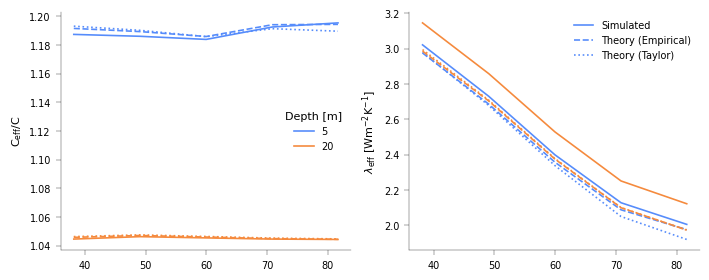

In [14]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=False)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.depth.size):
    ax[0].plot(ds.lat, heat_cap_mult.isel(depth=i), color=f'C{i}', label=f'{ds.depth[i]:.0f}')
    ax[0].plot(ds.lat, heat_cap_mult_theory.isel(depth=i), color=f'C{i}', linestyle='--')
    ax[0].plot(ds.lat, heat_cap_mult_theory_old.isel(depth=i), color=f'C{i}', linestyle=':')
    ax[1].plot(ds.lat, lambda_s1_eff.isel(depth=i), color=f'C{i}', label='Simulated' if i == 0 else None)
    ax[1].plot(ds.lat, lambda_s1_eff_theory.isel(depth=i), color=f'C{i}', linestyle='--',
               label='Theory (Empirical)' if i == 0 else None)
    ax[1].plot(ds.lat, lambda_s1_eff_theory_old.isel(depth=i), color=f'C{i}', linestyle=':',
               label='Theory (Taylor)' if i == 0 else None)
update_linewidth(fig)
ax[0].legend(title='Depth [m]')
ax[1].legend()
update_linewidth(fig)
ax[0].set_ylabel("C$_{\\text{eff}}/$C")
ax[1].set_ylabel("$\lambda_{\\text{eff}}$ [Wm$^{-2}\\text{K}^{-1}$]")
plt.show()

### Phase and Amplitude
The two layer model also gives theoretical estimates for phase and amplitude of lowest model level temperature, so I include those here too.

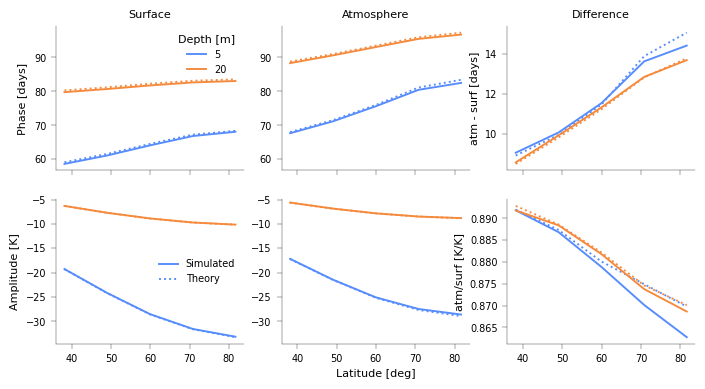

In [15]:
fig, ax = plt.subplots(2, 3, sharex=True, sharey=False)
fig_resize(fig, utils.width['two_col'] * 1.5)
ax = ax.flatten()
for i in range(ds.depth.size):
    ax[0].plot(ds.lat, coef_phase.isel(depth=i)/omega/utils.day_seconds, color=f'C{i}', label=f'{ds.depth[i]:.0f}')
    ax[0].plot(ds.lat, coef_phase_theory.isel(depth=i)/omega/utils.day_seconds, color=f'C{i}', linestyle=':')
    ax[3].plot(ds.lat, coef_amp.isel(depth=i), color=f'C{i}', label='Simulated' if i == 0 else None)
    ax[3].plot(ds.lat, coef_amp_theory.isel(depth=i), color=f'C{i}', linestyle=':',
               label='Theory' if i == 0 else None)
    ax[1].plot(ds.lat, coef_phase_atm.isel(depth=i)/omega/utils.day_seconds, color=f'C{i}')
    ax[1].plot(ds.lat, coef_phase_theory_atm.isel(depth=i)/omega/utils.day_seconds, color=f'C{i}', linestyle=':')
    ax[4].plot(ds.lat, coef_amp_atm.isel(depth=i), color=f'C{i}', label='Simulated' if i == 0 else None)
    ax[4].plot(ds.lat, coef_amp_theory_atm.isel(depth=i), color=f'C{i}', linestyle=':',
               label='Theory' if i == 0 else None)
    ax[2].plot(ds.lat, (coef_phase_atm-coef_phase).isel(depth=i)/omega/utils.day_seconds, color=f'C{i}')
    ax[2].plot(ds.lat, (coef_phase_theory_atm-coef_phase_theory).isel(depth=i)/omega/utils.day_seconds, color=f'C{i}', linestyle=':')
    ax[5].plot(ds.lat, (coef_amp_atm/coef_amp).isel(depth=i), color=f'C{i}')
    ax[5].plot(ds.lat, (coef_amp_theory_atm/coef_amp_theory).isel(depth=i), color=f'C{i}', linestyle=':')
ax[1].sharey(ax[0])
ax[4].sharey(ax[3])
update_linewidth(fig, 1.8)
ax[0].legend(title='Depth [m]')
ax[3].legend()
ax[0].set_ylabel("Phase [days]")
ax[3].set_ylabel("Amplitude [K]")
ax[2].set_ylabel("atm - surf [days]")
ax[5].set_ylabel("atm/surf [K/K]")
ax[0].set_title('Surface')
ax[1].set_title('Atmosphere')
ax[2].set_title('Difference')
ax[4].set_xlabel('Latitude [deg]')
plt.show()